In [32]:
import cv2
import matplotlib.pyplot as plt
import functions as calib
import glob
import os
%load_ext autoreload
%autoreload 2
# Matplotlib configuration for displaying images inline
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import functions as calib

# 1. Print exactly which file Python is loading
print("File location:", calib.__file__)

# 2. Print every function Python can see inside that file
print("Available functions:", [f for f in dir(calib) if not f.startswith('__')])

File location: c:\Users\Felix\Dokumente\Git Repos\Camera_Calibration\functions.py
Available functions: ['calculate_reprojection_error', 'calibrate_camera', 'cv2', 'get_calibration_points', 'glob', 'np', 'os', 'undistort_image']


In [34]:
# Directory containing your checkerboard images
IMAGE_DIR = 'camera_calibration_imgs'
IMAGE_FORMAT = 'png'

# Number of INNER corners on the chessboard (width, height)
# Note: A standard 10x7 squares chessboard has 9x6 inner corners
GRID_SIZE = (11,7) 

# Real-world size of a single square (e.g., 2.5 cm)
SQUARE_SIZE = 3

In [35]:
print("Extracting points from images...")
try:
    objpoints, imgpoints, img_shape = calib.get_calibration_points(
        IMAGE_DIR, IMAGE_FORMAT, GRID_SIZE, SQUARE_SIZE
    )
    print(f"Successfully processed {len(imgpoints)} images.")
    
    print("\nCalibrating camera...")
    ret, mtx, dist, rvecs, tvecs = calib.calibrate_camera(objpoints, imgpoints, img_shape)
    
    print("\nCalibration Successful!")
    print("\nCamera Matrix:\n", mtx)
    print("\nDistortion Coefficients:\n", dist)
    
except Exception as e:
    print(f"An error occurred: {e}")

Extracting points from images...
Successfully processed 20 images.

Calibrating camera...

Calibration Successful!

Camera Matrix:
 [[718.91823831   0.         523.81819578]
 [  0.         729.96806939 285.67619196]
 [  0.           0.           1.        ]]

Distortion Coefficients:
 [[ 3.10648842e-02 -1.79709599e-01  8.74315025e-04  1.77034367e-04
   2.13728786e-01]]


In [36]:
# A lower error (closer to 0) means a better calibration
error = calib.calculate_reprojection_error(objpoints, imgpoints, rvecs, tvecs, mtx, dist)
print(f"Total Reprojection Error: {error:.4f} pixels")

Total Reprojection Error: 0.0210 pixels


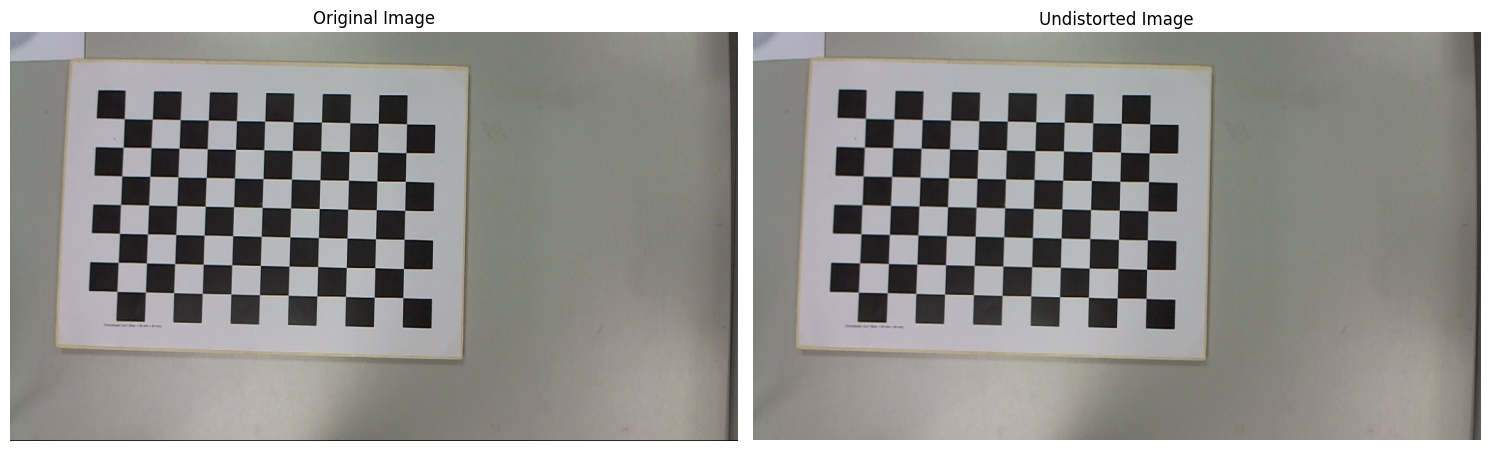

In [37]:
# Grab the first image from the directory to test
test_image_path = glob.glob(os.path.join(IMAGE_DIR, f'*.{IMAGE_FORMAT}'))[0]

# Use the module function to undistort
original_img, undistorted_img = calib.undistort_image(test_image_path, mtx, dist)

# Convert BGR to RGB for correct matplotlib rendering
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted_img, cv2.COLOR_BGR2RGB)

# Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

axes[0].imshow(original_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(undistorted_rgb)
axes[1].set_title('Undistorted Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

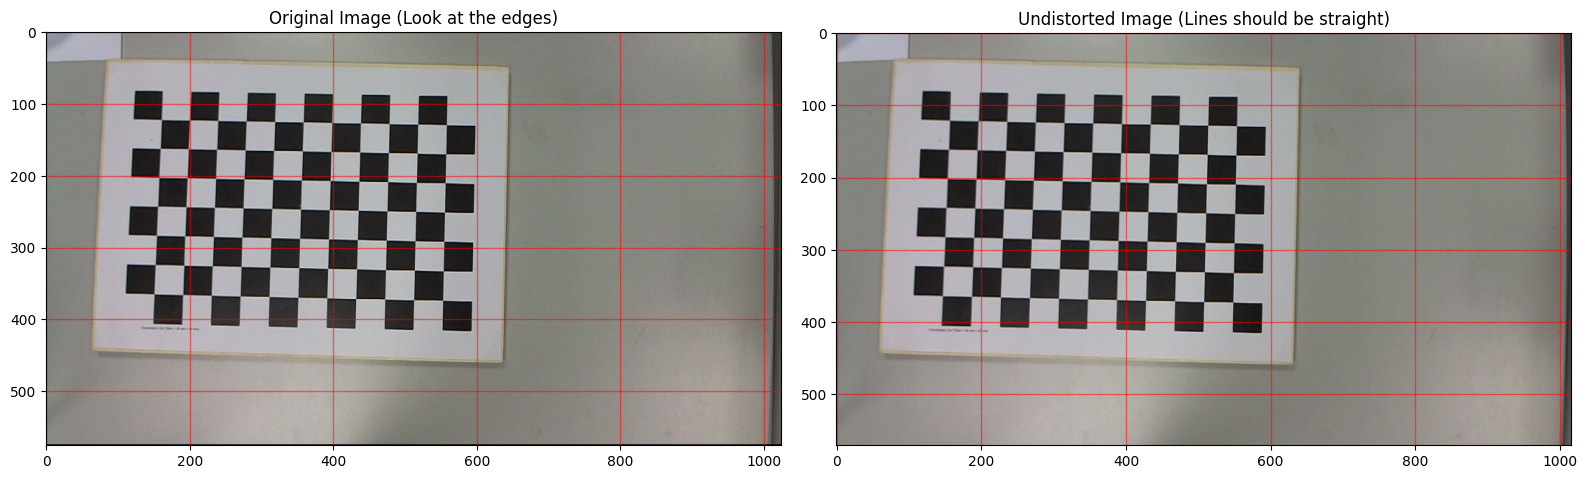

In [38]:
import glob
import os
import cv2
import matplotlib.pyplot as plt

# Grab one of your checkerboard images (try to pick one where the board is near the edge)
test_image_path = glob.glob(os.path.join(IMAGE_DIR, f'*.{IMAGE_FORMAT}'))[0]

# Undistort it using our function
original_img, undistorted_img = calib.undistort_image(test_image_path, mtx, dist)

# Convert to RGB for matplotlib
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Original Image with a Grid
axes[0].imshow(original_rgb)
axes[0].set_title('Original Image (Look at the edges)')
axes[0].axis('on')
# Overlay a tight grid to make curves obvious
axes[0].grid(color='red', linestyle='-', linewidth=1, alpha=0.5) 

# 2. Undistorted Image with a Grid
axes[1].imshow(undistorted_rgb)
axes[1].set_title('Undistorted Image (Lines should be straight)')
axes[1].axis('on')
axes[1].grid(color='red', linestyle='-', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

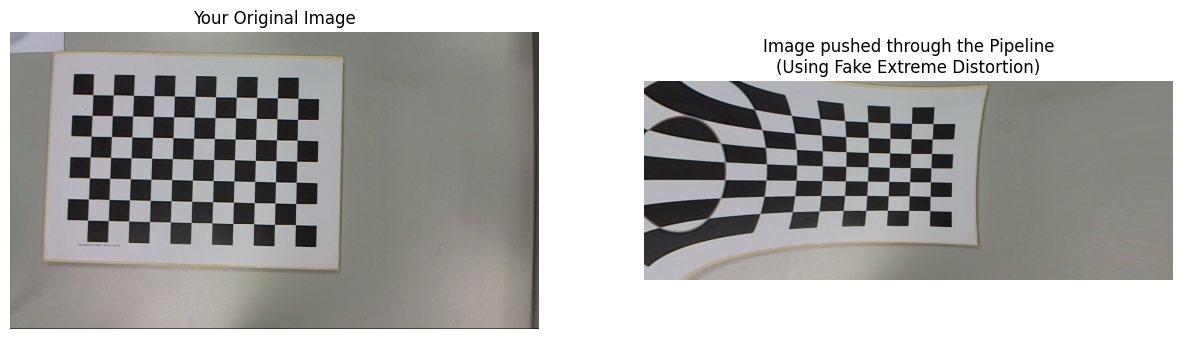

In [39]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import os

# 1. Grab a test image
test_image_path = glob.glob(os.path.join(IMAGE_DIR, f'*.{IMAGE_FORMAT}'))[0]
original_img = cv2.imread(test_image_path)
h, w = original_img.shape[:2]

# 2. CREATE FAKE DISTORTION
# We are overriding your real calibration with a massive "Barrel" distortion (-0.8)
fake_dist = np.array([[-0.8, 0.0, 0.0, 0.0, 0.0]]) 

# 3. Use the fake distortion to process the image
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, fake_dist, (w, h), 1, (w, h))
fake_undistorted_img = cv2.undistort(original_img, mtx, fake_dist, None, newcameramtx)

# Crop it
x, y, w_roi, h_roi = roi
fake_undistorted_img = fake_undistorted_img[y:y+h_roi, x:x+w_roi]

# 4. Plot the results
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
fake_rgb = cv2.cvtColor(fake_undistorted_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(original_rgb)
axes[0].set_title('Your Original Image')
axes[0].axis('off')

axes[1].imshow(fake_rgb)
axes[1].set_title('Image pushed through the Pipeline\n(Using Fake Extreme Distortion)')
axes[1].axis('off')

plt.show()